<a href="https://colab.research.google.com/github/Ragorrison/CASOS-DE-ESTUDIO/blob/main/notebooks/PregPCA_2026_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Valores y vectores propios de una matriz simétrica

https://www.kaggle.com/code/lkskrk/community-help-via-multivariate-anomaly-detection


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

#Análisis de componentes principales

Responda las siguientes preguntas:

¿Qué son vectores y valores propios de una matriz cuadrada?

¿Qué es una matriz simétrica?

¿Qué se llama descomposción espectral de una matriz simétrica?

¿Explique brevemente, cómo se determina una proyección sobre un espacio vectorial de dimensión 1?

In [ ]:
df = pd.read_csv(  filepath_or_buffer='https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
    header=None,
    sep=',')

df.columns=['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
df.dropna(how="all", inplace=True) # drops the empty line at file-end
df.tail()


,sepal_len,sepal_wid,petal_len,petal_wid,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
from numpy.linalg import eig,det

In [ ]:
X = df.iloc[:,0:4]
X_std = StandardScaler().fit_transform(X)
mean_vec = np.mean(X_std, axis=0)
cov_mat = np.cov(X_std, rowvar=False)
cov_mat

array([[ 1.00671141, -0.11010327,  0.87760486,  0.82344326],
       [-0.11010327,  1.00671141, -0.42333835, -0.358937  ],
       [ 0.87760486, -0.42333835,  1.00671141,  0.96921855],
       [ 0.82344326, -0.358937  ,  0.96921855,  1.00671141]])

In [ ]:
eig_vals, eig_vecs = eig(cov_mat)

print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)


Eigenvectors 
[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]

Eigenvalues 
[2.93035378 0.92740362 0.14834223 0.02074601]


In [ ]:
#X=df.values

#Scaling the values
#X = scale(X)

pca = PCA(n_components=4)

modeloPCA=pca.fit(X_std)


In [ ]:
modeloPCA.components_

array([[ 0.52237162, -0.26335492,  0.58125401,  0.56561105],
       [ 0.37231836,  0.92555649,  0.02109478,  0.06541577],
       [ 0.72101681, -0.24203288, -0.14089226, -0.6338014 ],
       [-0.26199559,  0.12413481,  0.80115427, -0.52354627]])

In [ ]:
print(modeloPCA.explained_variance_ratio_)

[0.72770452 0.23030523 0.03683832 0.00515193]


In [ ]:
pca = PCA(n_components=2)

modeloPCA_2=pca.fit(X_std)


In [ ]:
X_r = modeloPCA_2.transform(X_std)
X_rDf = pd.DataFrame(data = X_r
             , columns = ['principal component 1', 'principal component 2'])

In [ ]:
X_rDf.head()

,principal component 1,principal component 2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767


In [ ]:
modeloPCA_2.explained_variance_

array([2.93035378, 0.92740362])

In [ ]:
df_analysis2 = pd.concat([X_rDf, df['class']], axis=1)
display(df_analysis2.head())

,principal component 1,principal component 2,class
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


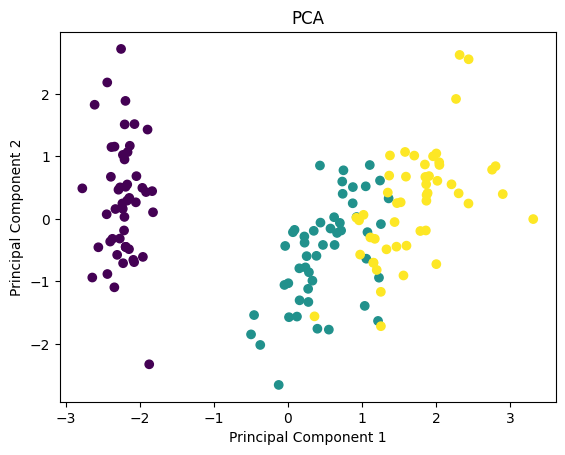

In [ ]:
plt.scatter(df_analysis2['principal component 1'],df_analysis2['principal component 2'], c=pd.factorize(df_analysis2['class'])[0])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA')
plt.show()

**Cargar un archivo de datos.**

In [ ]:
from google.colab import files
carga=files.upload()

In [ ]:
import io

In [ ]:
import pandas as pd
df2_feb=pd.read_excel('compras1.xlsx')

df2_feb.tail(3)

In [ ]:

import pandas as pd
dfacp2=pd.read_csv('/content/Prostate_Cancer.csv',encoding='unicode_escape',sep=',')
dfacp2.head()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sajidsaifi/prostate-cancer")

print("Path to dataset files:", path)

100%|██████████| 1.83k/1.83k [00:00<00:00, 3.64MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sajidsaifi/prostate-cancer/versions/1


In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
file_path = os.path.join(path, 'Prostate_Cancer.csv')

# Read the CSV file into a pandas DataFrame
df_prostate = pd.read_csv(file_path)

# Display the first few rows
display(df_prostate.head())

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059


eliminar la columna grupo

In [ ]:
dfacp=df_prostate.drop(['id','diagnosis_result'],axis=1)
dfacp.head()
# O bien X = dfacp.drop(columns='grupo')

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,23,12,151,954,0.143,0.278,0.242,0.079
1,9,13,133,1326,0.143,0.079,0.181,0.057
2,21,27,130,1203,0.125,0.160,0.207,0.060
3,14,16,78,386,0.070,0.284,0.260,0.097
4,9,19,135,1297,0.141,0.133,0.181,0.059


In [ ]:
from google.colab import files

In [ ]:
df_analysis2.to_excel('dfpca.xlsx',index=False)

In [ ]:
files.download('dfpca.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>